## Retry and Delay

In [1]:
import os
import time
import logging
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Initialize LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

def call_llm_with_retry(prompt, retries=3, delay=2):
    for attempt in range(1, retries + 1):
        try:
            logging.info(f"Attempt {attempt} - Calling LLM")
            
            response = llm.invoke([HumanMessage(content=prompt)])
            
            logging.info("LLM call successful")
            return response.content
        
        except Exception as e:
            logging.error(f"Attempt {attempt} failed: {e}")
            
            if attempt < retries:
                time.sleep(delay)
            else:
                logging.critical("All retry attempts failed")
                raise

# Example usage
if __name__ == "__main__":
    prompt = "Explain what is an API in one sentence"
    
    result = call_llm_with_retry(prompt)
    print("Final Response:", result)

/Users/ishant162/miniconda3/envs/rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-27 12:03:24,666 - INFO - Attempt 1 - Calling LLM
2026-04-27 12:03:25,091 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 12:03:25,099 - INFO - LLM call successful


Final Response: An API, or Application Programming Interface, is a set of defined rules and protocols that allows different software systems, applications, or services to communicate and exchange data with each other.


## Simple RAG

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path
import uuid
import chromadb
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

# ── Config ────────────────────────────────────────────────────────────────────
PDF_DIR        = "./data/"
VECTOR_DIR     = "./data/vector_store"
EMBED_MODEL    = "all-MiniLM-L6-v2"
CHUNK_SIZE     = 1000
CHUNK_OVERLAP  = 200
TOP_K          = 3

# ── 1. Load PDFs ──────────────────────────────────────────────────────────────
docs = []
for pdf in Path(PDF_DIR).glob("**/*.pdf"):
    docs.extend(PyPDFLoader(str(pdf)).load())
print(f"Loaded {len(docs)} pages")

# ── 2.1 Fixed Chunk ──────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = splitter.split_documents(docs)
print(f"Split into {len(chunks)} chunks")

# ── 2.2 Semantic Chunk ──────────────────────────────────────────────────────────────────

# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
# splitter = SemanticChunker(
#     embeddings=embeddings,
#     breakpoint_threshold_type="percentile",
#     breakpoint_threshold_amount=70
# )
# chunks = splitter.split_documents(docs)
# print(f"Split into {len(chunks)} semantic chunks")

# ── 3. Embed ──────────────────────────────────────────────────────────────────
model = SentenceTransformer(EMBED_MODEL)
texts = [c.page_content for c in chunks]
embeddings = model.encode(texts, show_progress_bar=True)

# ── 4. Store in ChromaDB ──────────────────────────────────────────────────────
os.makedirs(VECTOR_DIR, exist_ok=True)

# Check write access
if not os.access(VECTOR_DIR, os.W_OK):
    raise PermissionError(f"No write permission for {VECTOR_DIR}")

client     = chromadb.PersistentClient(path=VECTOR_DIR)
collection = client.get_or_create_collection("pdf_documents")

collection.add(
    ids        = [f"doc_{uuid.uuid4().hex[:8]}_{i}" for i in range(len(chunks))],
    embeddings = embeddings.tolist(),
    documents  = texts,
    metadatas  = [c.metadata for c in chunks]
)
print(f"Stored {collection.count()} chunks in vector store")


2026-04-27 12:03:29,497 - INFO - Use pytorch device_name: mps
2026-04-27 12:03:29,497 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loaded 53 pages
Split into 229 chunks


Batches: 100%|██████████| 8/8 [00:01<00:00,  5.28it/s]
2026-04-27 12:03:35,675 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


Stored 458 chunks in vector store


In [3]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# ── Shared setup (reuse model + collection from the main pipeline) ─────────────
texts        = [c.page_content for c in chunks]   # already have this from pipeline
tokenized    = [t.lower().split() for t in texts]
bm25         = BM25Okapi(tokenized)
reranker     = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# ── BM25 search ───────────────────────────────────────────────────────────────
def bm25_search(query, top_k):
    scores     = bm25.get_scores(query.lower().split())
    top_idx    = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [{"id": f"bm25_{i}", "content": texts[i], "score": scores[i]} for i in top_idx if scores[i] > 0]

# ── Vector search ─────────────────────────────────────────────────────────────
def vector_search(query, top_k):
    q_emb   = model.encode([query])[0].tolist()   # reuse SentenceTransformer from pipeline
    results = collection.query(query_embeddings=[q_emb], n_results=top_k)
    return [
        {"id": doc_id, "content": doc, "score": 1 - dist}
        for doc_id, doc, dist in zip(results["ids"][0], results["documents"][0], results["distances"][0])
    ]

# ── Reciprocal Rank Fusion ────────────────────────────────────────────────────
def rrf(bm25_results, vector_results, k=60):
    scores, doc_map = {}, {}
    for rank, doc in enumerate(bm25_results + vector_results, 1):
        scores[doc["id"]]  = scores.get(doc["id"], 0) + 1 / (k + rank)
        doc_map[doc["id"]] = doc
    return [doc_map[i] for i in sorted(scores, key=lambda x: scores[x], reverse=True)]

# ── RAG variants ──────────────────────────────────────────────────────────────
def rag(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search(query, top_k)
    return _generate(query, results)

def rag_hybrid(query, top_k=3):
    """BM25 + Vector fused via RRF"""
    results = rrf(bm25_search(query, top_k * 3), vector_search(query, top_k * 3))[:top_k]
    print("Results from rag_hybrid:", results)
    return _generate(query, results)

def rag_hybrid_rerank(query, top_k=3):
    """BM25 + Vector → RRF → CrossEncoder rerank"""
    candidates = rrf(bm25_search(query, top_k * 4), vector_search(query, top_k * 4))[:top_k * 2]
    scores     = reranker.predict([(query, d["content"]) for d in candidates])
    results    = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:top_k]
    print("Results from rag_hybrid_rerank:", results)
    return _generate(query, [d for d, _ in results])

def rag_hyde(query, top_k=3):
    """HyDE: generate hypothetical answer → use it for retrieval"""
    hypo    = llm.invoke([f"Write a concise answer to: {query}"]).content
    results = rrf(bm25_search(hypo, top_k * 3), vector_search(hypo, top_k * 3))[:top_k]
    print("Results from rag_hyde:", results)
    return _generate(query, results)

# ── Shared answer generator ───────────────────────────────────────────────────
def _generate(query, results):
    context = "\n\n".join([d["content"] for d in results])
    if not context:
        return "No relevant context found."
    prompt = f"Use the context below to answer the question.\n\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return llm.invoke([prompt]).content

# ── Run ───────────────────────────────────────────────────────────────────────
q = "Explain in simple terms about the paper Photon rings and shadows of black holes with non-minimal couplings between curvature and electromagnetic field"

print("*"*50)
print("Basic RAG")
print(rag(q))
print("*"*50)
print("Hybrid RAG")
print(rag_hybrid(q))
print("*"*50)
print("Hybrid RAG rerank")
print(rag_hybrid_rerank(q))
print("*"*50)
print("Hyde RAG")
print(rag_hyde(q))
print("*"*50)

2026-04-27 12:03:38,671 - INFO - Use pytorch device: mps


**************************************************
Basic RAG


Batches: 100%|██████████| 1/1 [00:00<00:00, 15.82it/s]
2026-04-27 12:03:40,284 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The paper "Photon rings and shadows of black holes with non-minimal couplings between curvature and electromagnetic field" is about black holes and how they behave when their gravity and electromagnetic fields interact in non-standard ways. 

In simple terms, the researchers are studying what happens when the gravity of a black hole and its electromagnetic field (like light and other forms of electromagnetic radiation) interact with each other in ways that are not predicted by traditional theories of gravity, such as Einstein's theory of general relativity.

They are looking at how these interactions affect the appearance of black holes, particularly the "shadows" they cast and the "photon rings" that form around them. The researchers are using complex mathematical equations to model these interactions and understand how they change our understanding of black holes.

The goal of the paper is to better understand how black holes behave in extreme environments and how their gravity and e

Batches: 100%|██████████| 1/1 [00:00<00:00, 60.67it/s]


...

This paper is about understanding how black holes behave when they are affected by the interaction between the curvature of space and the electromagnetic field. The researchers are trying to figure out how this interaction changes the appearance of black holes, including the size of their shadows and the paths that light takes around them. They are using complex math and computer simulations to study this phenomenon and to see how it can help us better understand the nature of gravity and the behavior of black holes. Ultimately, the goal is to use observations of black holes to test whether our current understanding of gravity is correct or if there are other forces at play.
**************************************************
Hyde RAG


2026-04-27 12:03:43,378 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
Batches: 100%|██████████| 1/1 [00:00<00:00,  3.35it/s]


Results from rag_hyde: [{'id': 'bm25_104', 'content': 'zero, leading to their effective coincidence at the shadow\nboundary.\nFigure 23 illustrates the corresponding black hole im-\nages for increasingα 3. It is clear that the radius of\nthe zeroth-order photon ring grows rapidly, accompanied\nby a significant increase in the separation between the\nzeroth- and first-order photon rings.\nVII. CONCLUSION AND DISCUSSION\nIn conclusion, we have conducted a study on the\nstructure of black holes with non-minimal couplings be-\ntween spacetime curvature tensors and the electromag-\nnetic field, including size of horizon, photon sphere,\nshadow and photon rings. By the observations of photon\nrings and shadows of black holes, we can make observa-\ntional constraints on these non-minimal couplings. From\nthis, we might discover the modifications to the theory\nof gravity caused by classical or quantum effects.\nWe derived a series solution for a Reissner–Nordstr¨ om-\nlike black hole with non

2026-04-27 12:03:44,991 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The paper is about studying black holes and how they look when they have a special kind of connection between the way space is curved and the way electricity and magnetism work. This connection is called a "non-minimal coupling" and it can affect how black holes look, especially their "shadows" and "photon rings".

Imagine you're taking a picture of a black hole. The shadow is like the dark shape of the black hole, and the photon rings are like the bright rings of light around it. The paper says that when you have this special connection, it can make the shadow bigger or smaller, and it can also change the size and brightness of the photon rings.

The researchers found that different kinds of connections can have different effects on the black hole's appearance. For example, one kind of connection can make the shadow bigger and the photon rings brighter, while another kind can make the shadow smaller and the photon rings less bright.

The paper is important because it can help us learn

## RAGAS

In [4]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_huggingface import HuggingFaceEmbeddings

# ── Eval dataset ──────────────────────────────────────────────────────────────
eval_questions = [
    "What is attention is all you need?",
    "What is multi-head attention?",
    # add more questions...
]

# ground truth answers for context_recall / context_precision
ground_truths = [
    "Attention is all you need is a paper that introduced the transformer architecture.",
    "Multi-head attention runs attention multiple times in parallel.",
]

# ── Build RAGAS dataset ───────────────────────────────────────────────────────
data = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

for question, truth in zip(eval_questions, ground_truths):
    results  = vector_search(question, top_k=3)
    contexts = [d["content"] for d in results]
    answer   = _generate(question, results)

    data["question"].append(question)
    data["answer"].append(answer)
    data["contexts"].append(contexts)
    data["ground_truth"].append(truth)

# ── Evaluate ──────────────────────────────────────────────────────────────────

ragas_llm        = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))

dataset = Dataset.from_dict(data)
# pass them into each metric
scores = evaluate(
    dataset,
    metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

print(scores)
scores.to_pandas()

/var/folders/wc/rwpfcb3n6ysfjqkkml8ynztr0000gn/T/ipykernel_27146/3694246222.py:2: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/wc/rwpfcb3n6ysfjqkkml8ynztr0000gn/T/ipykernel_27146/3694246222.py:2: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/wc/rwpfcb3n6ysfjqkkml8ynztr0000gn/T/ipykernel_27146/3694246222.py:2: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

{'faithfulness': 0.5500, 'answer_relevancy': 0.7980, 'context_precision': 0.7917, 'context_recall': 0.5000}


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,What is attention is all you need?,[3.2 Attention\nAn attention function can be d...,"The text does not explicitly state ""Attention ...",Attention is all you need is a paper that intr...,0.1,0.713840,1.000000,0.0
1,What is multi-head attention?,[3.2 Attention\nAn attention function can be d...,Multi-head attention is a type of attention me...,Multi-head attention runs attention multiple t...,1.0,0.882112,0.583333,1.0


## RAG with Pinecone

In [5]:
########### Setting up Pinecone
from pinecone import Pinecone

pinecone_api_key = os.getenv("pinecone_api_key")

pc = Pinecone(api_key=pinecone_api_key)


########### Setting up Pinecone index
index = pc.Index("ragtest")

vectors = [
    (f"doc_{i}", embeddings[i].tolist(), {"text": texts[i]})
    for i in range(len(texts))
]


########### Injesting embeddings in the index
index.upsert(vectors=vectors)
print(f"Upserted {len(vectors)} vectors")

########### Function to do vector search in Pinecone
def vector_search_pinecone(query, top_k):
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("vector search called")
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

########### RAG with Pinecone
def rag_pinecone(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search_pinecone(query, top_k)
    return _generate(query, results)

print(rag_pinecone(q))

Upserted 229 vectors
**************************************************
**************************************************
**************************************************
**************************************************
vector search called


Batches: 100%|██████████| 1/1 [00:00<00:00,  9.71it/s]
2026-04-27 12:04:39,788 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


This paper is about black holes and how they behave when they have a special kind of connection between their gravity (curvature) and the electromagnetic field (like light and other forms of energy). 

The researchers are trying to understand what happens when this connection is not minimal, meaning it's stronger than usual. They want to know how this affects the black hole's appearance, including its shadow (the dark area around a black hole) and photon rings (the bright rings of light around a black hole).

The paper uses complex math to study this connection and its effects on black holes. The researchers found that when this connection is stronger, the photon rings and shadow of the black hole change in size and shape. 

The goal of this research is to learn more about black holes and how they work, which can help us better understand the universe and the laws of physics. By studying the photon rings and shadows of black holes, scientists can gain insights into the underlying physi

### RAG Pinecone with metadata filtering

In [6]:
# ── Store with metadata ───────────────────────────────────────────────────────
vectors = [
    (
        f"doc_{i}",
        embeddings[i].tolist(),
        {
            "text":        texts[i],
            "source_file": chunks[i].metadata.get("source_file", ""),
            "page":        chunks[i].metadata.get("page", 0),
        }
    )
    for i in range(len(texts))
]
index.upsert(vectors=vectors)

# ── Vector search with filter ─────────────────────────────────────────────────
def vector_search_with_metadata_filtering(query, top_k, filter=None):
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True, filter=filter)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

query = "What is attention is all you need paper?"


# ── Usage examples ────────────────────────────────────────────────────────────
# Single file
vector_search_with_metadata_filtering(query, top_k=3, filter={"source_file": {"$eq": "attention.pdf"}})

# Specific pages
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$in": [1, 2, 3]}})

# Page range
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$gte": 5, "$lte": 10}})

# Multiple conditions (AND)
vector_search_with_metadata_filtering(query, top_k=3, filter={
    "source_file": {"$eq": "attention.pdf"},
    "page":        {"$gte": 5}
})


def rag_hybrid_with_meta_data(query, top_k=3, filter=None):
    results = rrf(
        bm25_search(query, top_k * 3),
        vector_search_with_metadata_filtering(query, top_k * 3, filter=filter)
    )[:top_k]
    return _generate(query, results)

# Usage
rag_hybrid_with_meta_data("What is attention?", filter={"source_file": {"$eq": "attention.pdf"}, "page": {"$in": [1, 2, 3]}})

Batches: 100%|██████████| 1/1 [00:00<00:00, 21.57it/s]
2026-04-27 12:04:44,079 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'The context provided does not give a direct definition of attention. However, based on the information given, it appears that attention refers to a mechanism in neural networks, specifically in the context of natural language processing, that allows the model to focus on certain parts of the input data (such as words or phrases) when processing it.\n\nIn the context of the transformer architecture, attention is a mechanism that enables the model to weigh the importance of different input elements (such as words) relative to each other. This is often visualized as a set of attention weights or scores that indicate the degree to which the model is "attending" to each input element.\n\nThe text also mentions "attention heads", which suggests that the model has multiple attention mechanisms that can focus on different aspects of the input data. The examples provided show how different attention heads can learn to perform different tasks, such as anaphora resolution (resolving pronoun refe

## Semantic Caching

In [7]:
import numpy as np

# ── Semantic Cache ────────────────────────────────────────────────────────────
cache = []   # list of {"embedding": ..., "query": ..., "answer": ...}
CACHE_THRESHOLD = 0.90   # cosine similarity threshold, tune as needed

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def check_cache(query_emb):
    for entry in cache:
        if cosine_similarity(query_emb, entry["embedding"]) >= CACHE_THRESHOLD:
            return entry["answer"]
    return None

def add_to_cache(query_emb, answer):
    cache.append({"embedding": query_emb, "answer": answer})

# ── RAG with semantic cache ───────────────────────────────────────────────────
def rag_with_semantic_caching(query, top_k=3):
    query_emb = model.encode([query])[0]

    # Check cache first
    cached = check_cache(query_emb)
    if cached:
        print("Cache hit!")
        return cached

    # Cache miss — run normal RAG
    results = vector_search(query, top_k)
    answer  = _generate(query, results)

    add_to_cache(query_emb, answer)
    return answer

In [8]:
answer = rag_with_semantic_caching("What is attention is all you need?")
print(answer)

Batches: 100%|██████████| 1/1 [00:00<00:00, 91.62it/s]
2026-04-27 12:04:45,011 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The context provided doesn't directly answer the question "What is attention is all you need?" However, based on the information given, it seems to be related to the concept of attention mechanisms in deep learning, particularly in the context of transformer models.

The phrase "Attention is All You Need" is actually the title of a research paper by Vaswani et al. (2017) that introduced the Transformer model, which relies heavily on self-attention mechanisms to process input sequences. In this context, the answer to the question would be that "Attention is All You Need" refers to the idea that attention mechanisms can be used as the primary component of a neural network architecture, replacing traditional recurrent neural network (RNN) or convolutional neural network (CNN) components.

In other words, the paper argues that attention mechanisms are sufficient to handle the complex dependencies and relationships in input data, and that they can be used to build powerful and efficient neu

## ReAct Pattern (Langchain Agent)

In [9]:
from langchain_core.tools import tool
from langchain.agents import create_agent

from langchain_groq import ChatGroq

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# 1. Define Tools
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

# 2. Create LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

# 3. Build ReAct Agent
agent = create_agent(llm, tools=[add, multiply])

# 4. Run
result = agent.invoke({
    "messages": [{"role": "user", "content": "what is 2+3*5"}]
})

# 5. Print final answer
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")

2026-04-27 12:04:45,830 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 12:04:46,238 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


human: what is 2+3*5
ai: 
tool: 15
tool: 17
ai: The calculation 2+3*5 follows the order of operations (PEMDAS), which means multiplication is performed before addition. 

First, 3 is multiplied by 5, which equals 15. Then, 2 is added to 15, resulting in a final answer of 17.


## ReAct Pattern (Using Langgraph)

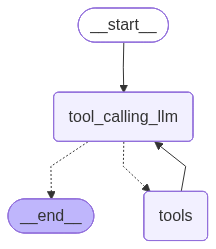

2026-04-27 12:04:46,753 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-04-27 12:04:46,755 - INFO - Retrying request to /openai/v1/chat/completions in 1.000000 seconds
2026-04-27 12:04:48,255 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-27 12:04:48,772 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

add 3 plus 3 , and then multiply by 6
================================== Ai Message ==================================
Tool Calls:
  add (2sawnmsdb)
 Call ID: 2sawnmsdb
  Args:
    a: 3
    b: 3
  multiply (9vv1hqvfe)
 Call ID: 9vv1hqvfe
  Args:
    a: 6
    b: 6
================================= Tool Message =================================
Name: add

6
================================= Tool Message =================================
Name: multiply

36
================================== Ai Message ==================================

First, we added 3 plus 3 which equals 6. Then we multiplied 6 by 6 which equals 36.


In [10]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage



## Custom functions for reACT agents

def multiply(a:int, b:int)-> int:
    """Multiplies two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a * b

# Tool
def add(a:int, b:int)-> int:
    """Adds two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a + b

def divide(a:int, b:int)-> float:
    """Divides two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.    
    """
    return a / b


tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)


class State(TypedDict):
    """State for the graph."""
    messages: Annotated[list[AnyMessage], add_messages]


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

messages = graph.invoke({"messages":HumanMessage(content="add 3 plus 3 , and then multiply by 6")})
for msg in messages["messages"]:
    msg.pretty_print()

## Plan and execute Pattern

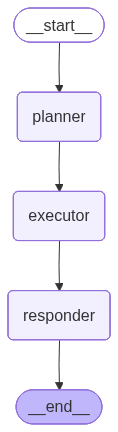

2026-04-27 12:04:51,995 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


**************************************************
{'query': '1. **Identify credible sources**: Look for reputable websites, academic journals, and research institutions that publish information on AI agents, such as MIT, Stanford, and top tech blogs.', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://hai.stanford.edu/assets/files/ai_index_report_2026.pdf', 'title': 'Artificial Intelligence Index Report | Stanford HAI', 'content': '“The AI Index 2026 Annual Report,” AI Index Steering Committee, Institute for. Human-Centered AI, Stanford University, Stanford, CA, April 2026. ... AI agents', 'score': 0.57952, 'raw_content': None}, {'url': 'https://www.linkedin.com/posts/umangvohra_10-breakthrough-technologies-2026-activity-7432758729726619648-iesd', 'title': 'MIT Tech Review: Breakthroughs in Biotech, AI, and ...', 'content': 'AI agents change the equation entirely. Not copilots. Not chatbots. Autonomous research collaborators — scanning literature 

2026-04-27 12:05:01,479 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-04-27 12:05:01,481 - INFO - Retrying request to /openai/v1/chat/completions in 9.000000 seconds


**************************************************
{'query': '3. **Explore online communities and forums**: Visit online forums, social media groups, and specialized platforms where AI experts and researchers share their findings, discuss new trends, and collaborate on projects related to AI agents.', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.analyticsinsight.net/artificial-intelligence/best-ai-forums-and-communities-for-2026', 'title': 'Best Online Communities for AI Knowledge', 'content': '# Best AI Forums and Communities for 2026. * Online AI communities enable shared learning through tools and real discussions. AI is everywhere now, and online communities are helping people understand it better. AI communities are no longer optional for people working in technology. As AI tools continue to spread, these communities will likely remain one of the main places where the future of the technology is shaped in practice. Why are online AI c

2026-04-27 12:05:10,558 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
2026-04-27 12:05:10,560 - INFO - Retrying request to /openai/v1/chat/completions in 2.000000 seconds
2026-04-27 12:05:14,548 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


PLAN:
  1. **Identify credible sources**: Look for reputable websites, academic journals, and research institutions that publish information on AI agents, such as MIT, Stanford, and top tech blogs.
  2. **Search for recent publications and articles**: Use search engines and databases to find recent articles, papers, and reports on AI agents, focusing on the latest developments and advancements in the field.
  3. **Explore online communities and forums**: Visit online forums, social media groups, and specialized platforms where AI experts and researchers share their findings, discuss new trends, and collaborate on projects related to AI agents.

RESULTS:
  Step: 1. **Identify credible sources**: Look for reputable websites, academic journals, and research institutions that publish information on AI agents, such as MIT, Stanford, and top tech blogs. → [{'url': 'https://hai.stanford.edu/assets/files/ai_index_report_2026.pdf', 'title': 'Artificial Intelligence Index Report | Stanford HAI',

In [11]:
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
from langchain_tavily import TavilySearch

os.environ["TAVILY_API_KEY"] = os.getenv("tavily_api_key")


# 1. State
class PlanExecuteState(TypedDict):
    input: str
    plan: List[str]
    results: List[str]
    final_answer: str

# 2. Tool
tavily = TavilySearch()
tavily.invoke("Provide me current news on UAE")

# 3. Planner Node — breaks task into steps
def planner(state: PlanExecuteState) -> PlanExecuteState:
    prompt = f"Break this task into 2-3 simple steps (as a numbered list):\n{state['input']}"
    response = llm.invoke(prompt)
    
    # Parse steps from response
    lines = response.content.strip().split("\n")
    steps = [l.strip() for l in lines if l.strip() and l[0].isdigit()]
    
    return {"plan": steps}

# 4. Executor Node — executes one step at a time
def executor(state: PlanExecuteState) -> PlanExecuteState:
    results = []
    for step in state["plan"]:
        result = tavily.invoke({"query": step})  # run tool per step
        print("*"*50)
        print(result)
        print("*"*50)
        results.append(f"Step: {step} → {result['results']}")
    return {"results": results}

# 5. Responder Node — synthesizes final answer
def responder(state: PlanExecuteState) -> PlanExecuteState:
    context = "\n".join(state["results"])
    prompt = f"Given these results:\n{context}\n\nAnswer the original question: {state['input']}"
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# 6. Build Graph
graph = StateGraph(PlanExecuteState)

graph.add_node("planner",  planner)
graph.add_node("executor", executor)
graph.add_node("responder", responder)

graph.set_entry_point("planner")
graph.add_edge("planner",  "executor")
graph.add_edge("executor", "responder")
graph.add_edge("responder", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

# # 7. Run
result = app.invoke({"input": "Research the latest trends in AI agents"})

print("PLAN:")
for step in result["plan"]:
    print(" ", step)

print("\nRESULTS:")
for r in result["results"]:
    print(" ", r)

print("\nFINAL ANSWER:")
print(result["final_answer"])